# Gradient Descent From Scratch

**Problem it solves:** given data, find the line (or curve) that fits it best — without solving for the answer in one shot algebraically.

**How it works:** start with a random guess for the parameters, measure how wrong you are (the loss), compute the *gradient* — the direction that makes the loss worse fastest — and step in the opposite direction. Repeat.

**When to use it:** basically always, under the hood — it's the training loop for linear regression, logistic regression, and every neural network you'll touch in later phases. You rarely write it by hand again after this notebook, but everything in [3_modern_ai](../3_modern_ai/README.md) assumes you understand what's happening inside `loss.backward()`.

No PyTorch, no autograd — just NumPy, so every step is visible.

## Step 1 — Make some data

We'll pretend the true relationship in the world is `y = 3x + 5`, plus some random noise (real data is never perfectly clean). Gradient descent doesn't get to see `3` and `5` — it only sees the noisy points, and has to *discover* something close to those numbers.

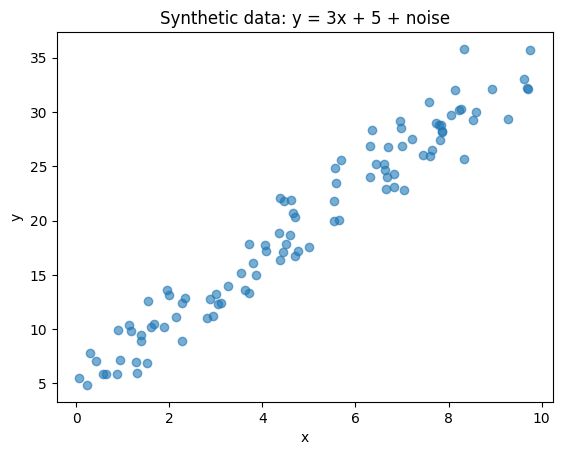

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

n = 100
x = rng.uniform(0, 10, n)
true_m, true_b = 3.0, 5.0
noise = rng.normal(0, 2.0, n)
y = true_m * x + true_b + noise

plt.scatter(x, y, alpha=0.6)
plt.title("Synthetic data: y = 3x + 5 + noise")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## Step 2 — Loss and gradients

We need a number that says "how wrong is our current guess?" — that's the **loss**. We'll use Mean Squared Error (MSE): average of `(prediction - actual)^2` over all points. Squaring punishes big misses more than small ones, and makes the math for the next step clean.

The **gradient** is just calculus: the partial derivative of the loss with respect to each parameter (`m` and `b`) tells you which direction increases the loss, and by how much. We step in the *opposite* direction to reduce it.

For `loss = mean((m*x + b - y)^2)`, the derivatives work out to:

```
d(loss)/dm = (2/n) * sum((m*x + b - y) * x)
d(loss)/db = (2/n) * sum(m*x + b - y)
```

That's it — no autograd magic, just the chain rule applied once.

In [2]:
def mse(x, y, m, b):
    y_pred = m * x + b
    return np.mean((y_pred - y) ** 2)


def compute_gradients(x, y, m, b):
    n = len(x)
    y_pred = m * x + b
    error = y_pred - y
    dm = (2 / n) * np.sum(error * x)
    db = (2 / n) * np.sum(error)
    return dm, db


# Sanity check: at m=0, b=0, the loss should just be mean(y^2)
print("Loss at m=0, b=0:", mse(x, y, 0, 0))
print("Gradients at m=0, b=0:", compute_gradients(x, y, 0, 0))

Loss at m=0, b=0: 454.34964119293284
Gradients at m=0, b=0: (np.float64(-235.23474094348364), np.float64(-39.14709454212787))


## Step 3 — The training loop

Start from a bad guess (`m=0, b=0`), then repeat: compute the gradient, take a small step opposite to it, measure the new loss. The step size is the **learning rate** — how big a step to take each time.

Learned: m=3.081, b=4.478  (true: m=3.0, b=5.0)


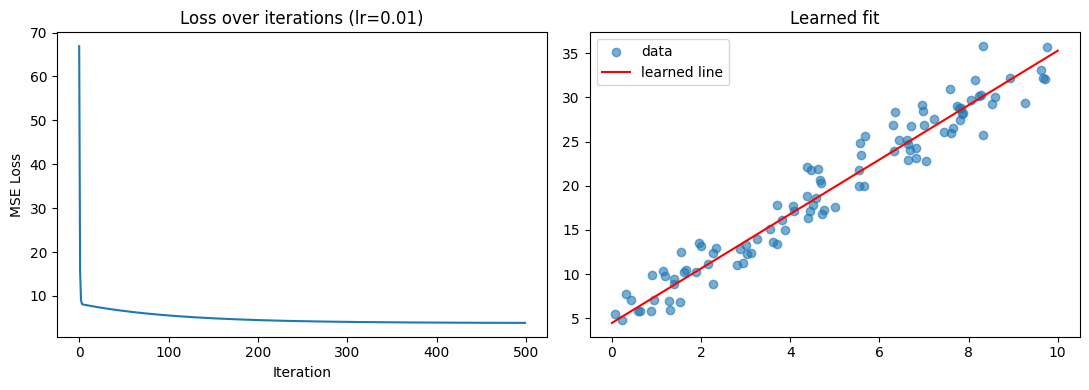

In [3]:
def gradient_descent(x, y, lr, n_iters, m_init=0.0, b_init=0.0):
    m, b = m_init, b_init
    loss_history = []
    for _ in range(n_iters):
        dm, db = compute_gradients(x, y, m, b)
        m -= lr * dm
        b -= lr * db
        loss_history.append(mse(x, y, m, b))
    return m, b, loss_history


m, b, loss_history = gradient_descent(x, y, lr=0.01, n_iters=500)
print(f"Learned: m={m:.3f}, b={b:.3f}  (true: m={true_m}, b={true_b})")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(loss_history)
axes[0].set_title("Loss over iterations (lr=0.01)")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("MSE Loss")

axes[1].scatter(x, y, alpha=0.6, label="data")
xs = np.linspace(0, 10, 2)
axes[1].plot(xs, m * xs + b, color="red", label="learned line")
axes[1].set_title("Learned fit")
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 4 — Why the learning rate matters

Too small, and you crawl toward the answer — correct, but wastes iterations. Too large, and each step overshoots the minimum by more than the last, so the loss grows instead of shrinks — it **diverges**.

The cell below runs three learning rates for the same number of iterations, so you can see convergence speed directly.

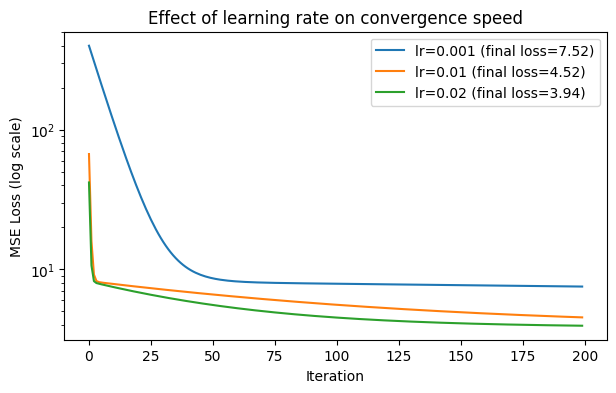

In [4]:
plt.figure(figsize=(7, 4))
for lr in [0.001, 0.01, 0.02]:
    _, _, history = gradient_descent(x, y, lr=lr, n_iters=200)
    plt.plot(history, label=f"lr={lr} (final loss={history[-1]:.2f})")

plt.yscale("log")
plt.legend()
plt.title("Effect of learning rate on convergence speed")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss (log scale)")
plt.show()

Now watch it actually diverge. At `lr=0.05` on this data, each step overshoots so badly the loss explodes within a handful of iterations — from a normal starting loss into the millions, then far beyond what a float can even hold.

In [5]:
_, _, diverging_history = gradient_descent(x, y, lr=0.05, n_iters=10)
for i, loss in enumerate(diverging_history):
    print(f"iteration {i}: loss = {loss:.4g}")

iteration 0: loss = 2141
iteration 1: loss = 1.021e+04
iteration 2: loss = 4.88e+04
iteration 3: loss = 2.334e+05
iteration 4: loss = 1.116e+06
iteration 5: loss = 5.337e+06
iteration 6: loss = 2.552e+07
iteration 7: loss = 1.221e+08
iteration 8: loss = 5.838e+08
iteration 9: loss = 2.792e+09


## Your turn — modify and debug on purpose

Before running each change, guess what will happen. Then run it and see if you were right.

1. Change `lr=0.05` above to `0.03`, then `0.021` — find roughly where it flips from converging to diverging.
2. Change `noise = rng.normal(0, 2.0, n)` to `rng.normal(0, 10.0, n)` (much noisier data) — does the learned `m` and `b` still land close to the true `3.0` and `5.0`? Why or why not?
3. Change `m_init=0.0` to `m_init=100.0` — does gradient descent still find the right answer? Does it take more or fewer iterations?
4. In your own words (no AI help), write 2–3 sentences answering: *what problem does gradient descent solve, how does it work, and when would you reach for it?*